In [121]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Input image

(np.float64(-0.5), np.float64(125.5), np.float64(108.5), np.float64(-0.5))

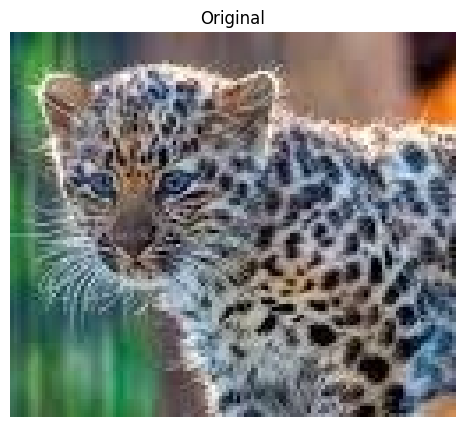

In [122]:
img_bgr = cv2.imread("img.jpg")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 1, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

In [123]:
def image_show(img_original, img_changed, title, figsize=(10, 5)):
    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.imshow(img_original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_changed)
    plt.title(title)
    plt.axis("off")

### Linear Interpolation

In [124]:
def linear_interpolation(image, scale):
    h, w, c = image.shape
    h_new, w_new = int(h * scale), int(w * scale)

    img_new = np.zeros((h_new, w_new, c), dtype=image.dtype)

    for i in range(h_new):
        for j in range(w_new):
            x = i / scale
            y = j / scale

            x0 = int(np.floor(x))
            x1 = min(x0 + 1, h - 1)
            y0 = int(np.floor(y))
            y1 = min(y0 + 1, w - 1)

            dx = x - x0
            dy = y - y0

            top = (1 - dx) * image[x0, y0] + dx * image[x1, y0]
            bottom = (1 - dx) * image[x0, y1] + dx * image[x1, y1]
            pixel = (1 - dy) * top + dy * bottom

            img_new[i, j] = pixel

    return img_new


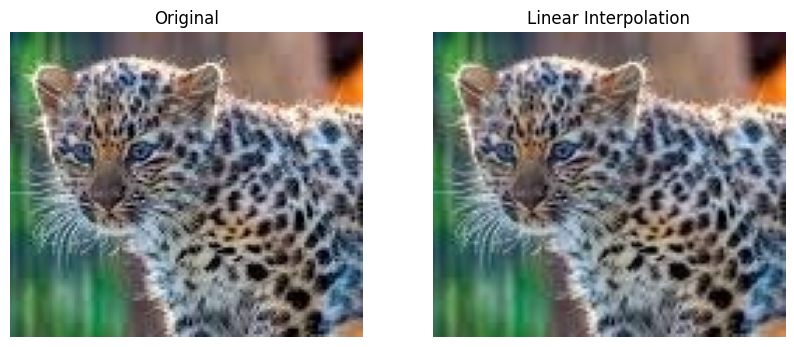

In [125]:
h, w = img.shape[:2]
scale = 2

h_new = h * scale
w_new = w * scale

X = np.arange(h)
Y = np.arange(w)
x_new = np.linspace(0, h - 1, h_new)
y_new = np.linspace(0, w - 1, w_new)

result = linear_interpolation(img, 2)

image_show(img, result, "Linear Interpolation")

### Polinomial Interpolation

In [126]:
def build_system(xx, yy):
    A = []
    B = []
    for x in xx:
        for y in yy:
            A.append([1, x, y, x * y])
            B.append([0, 0, 0])
    A = np.array(A)
    B = np.array(B)
    return np.linalg.lstsq(A, B, rcond=None)[0]


In [127]:
def polinom_summ(sol, x, y):
    return sol[0] + sol[1]*x + sol[2]*y + sol[3]*x*y

In [128]:
def interpolate_image(img, N_step_polinom):
    h, w = img.shape[:2]
    new_img = np.zeros_like(img, dtype=np.float32)

    nx = h // (N_step_polinom + 1)
    ny = w // (N_step_polinom + 1)

    for bx in range(nx):
        for by in range(ny):
            xx = np.linspace(bx * (N_step_polinom + 1), (bx + 1) * (N_step_polinom + 1), N_step_polinom + 1, dtype=int)
            yy = np.linspace(by * (N_step_polinom + 1), (by + 1) * (N_step_polinom + 1), N_step_polinom + 1, dtype=int)

            xx = np.clip(xx, 0, h - 1)
            yy = np.clip(yy, 0, w - 1)

            Xg, Yg = np.meshgrid(xx, yy, indexing='ij')
            A = np.stack([np.ones(Xg.size), Xg.ravel(), Yg.ravel(), (Xg*Yg).ravel()], axis=1)

            for c in range(3):
                B = img[Xg, Yg, c].ravel()
                sol, _, _, _ = np.linalg.lstsq(A, B, rcond=None)

                for i in range(xx[0], xx[-1] + 1):
                    for j in range(yy[0], yy[-1] + 1):
                        new_img[i, j, c] = polinom_summ(sol, i, j)

    return np.clip(new_img.astype(np.uint8), 0, 255)


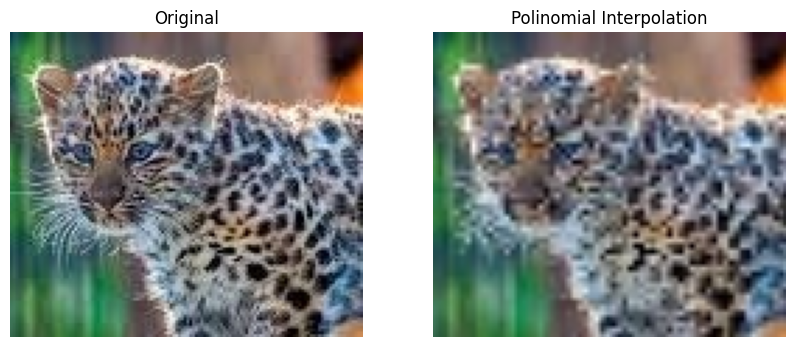

In [129]:
interpolated = interpolate_image(img, N_step_polinom=1)

image_show(img, interpolated, "Polinomial Interpolation")


### Interpolated Surface with Base Points

In [130]:
def build_vandermonde(x_points, degree):
    A = []
    for x in x_points:
        row = [1]
        for power in range(1, degree + 1):
            row.append(row[-1] * x)
        A.append(row)
    return A

def transpose_matrix(M):
    return [[M[j][i] for j in range(len(M))] for i in range(len(M[0]))]

def matmul(A, B):
    result = []
    rows_A = len(A)
    cols_A = len(A[0])
    cols_B = len(B[0])
    for i in range(rows_A):
        row_result = []
        for j in range(cols_B):
            s = 0
            for k in range(cols_A):
                s += A[i][k] * B[k][j]
            row_result.append(s)
        result.append(row_result)
    return result

def matvecmul(A, v):
    result = []
    for i in range(len(A)):
        s = 0
        for j in range(len(v)):
            s += A[i][j] * v[j]
        result.append(s)
    return result

def gaussian_elimination(A, b):
    n = len(A)
    for i in range(n):
        max_row = i
        for k in range(i + 1, n):
            if abs(A[k][i]) > abs(A[max_row][i]):
                max_row = k
        A[i], A[max_row] = A[max_row], A[i]
        b[i], b[max_row] = b[max_row], b[i]

        for k in range(i + 1, n):
            factor = A[k][i] / A[i][i]
            for j in range(i, n):
                A[k][j] -= factor * A[i][j]
            b[k] -= factor * b[i]

    x = [0] * n
    for i in range(n - 1, -1, -1):
        s = b[i]
        for j in range(i + 1, n):
            s -= A[i][j] * x[j]
        x[i] = s / A[i][i]
    return x

def least_squares_manual(x_points, y_points, degree):
    A = build_vandermonde(x_points, degree)
    AT = transpose_matrix(A)
    ATA = matmul(AT, A)
    ATy = matvecmul(AT, y_points)

    coeffs = gaussian_elimination(ATA, ATy)

    y_approx = []
    for row in A:
        val = 0
        for c, coef in enumerate(coeffs):
            val += coef * row[c]
        y_approx.append(val)

    return y_approx



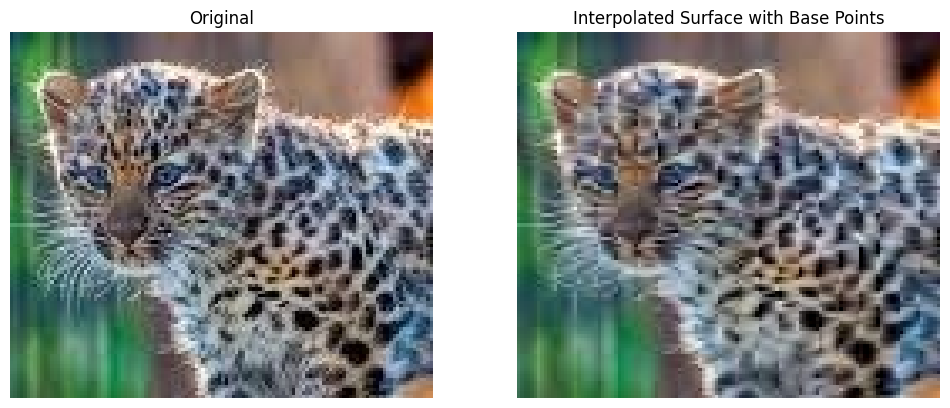

In [139]:
height, width, channels = img.shape

degree = 2
window_size = 6

img_interp = [[[0.0 for _ in range(channels)] for _ in range(width)] for _ in range(height)]

for row in range(height):
    for ch in range(channels):
        for start in range(0, width, window_size):
            end = min(start + window_size, width)
            x_seg = list(range(end - start))
            y_seg = [float(img[row, start + i, ch]) for i in x_seg]
            y_approx_seg = least_squares_manual(x_seg, y_seg, degree)
            for i, val in enumerate(y_approx_seg):
                img_interp[row][start + i][ch] = val

img_interp_np = np.array(img_interp)
img_interp_np = np.clip(img_interp_np, 0, 255).astype('uint8')

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Interpolated Surface with Base Points')
plt.imshow(img_interp_np)
plt.axis('off')

plt.show()